In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

import random
import numpy as np

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print(f"Random seed set to: {RANDOM_SEED}")

PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device: Tesla T4
VRAM: 15.64 GB
Using device: cuda
Random seed set to: 42


In [ ]:
import subprocess
import sys

packages = [
    "transformers>=4.30.0",
    "datasets>=2.10.0",
    "torch>=2.0.0",
    "accelerate>=0.20.0",
    "evaluate>=0.4.0",
    "pandas>=1.5.0",
    "numpy>=1.23.0",
    "matplotlib>=3.6.0",
    "seaborn>=0.12.0",
    "scikit-learn>=1.2.0",
]

print("Installing packages...")
for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("All packages installed successfully!")

Installing packages...
All packages installed successfully!


In [ ]:
import json
from pathlib import Path
from datetime import datetime
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    default_data_collator,
)

from datasets import load_dataset, DatasetDict
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

print("All imports successful!")

All imports successful!


In [ ]:
print("Loading IMDB dataset from Hugging Face...")
imdb_dataset = load_dataset("imdb")

print("Dataset splits:", imdb_dataset.keys())

train_data = imdb_dataset["train"]
test_data = imdb_dataset["test"]

print(f"Train size: {len(train_data)}, Test size: {len(test_data)}")

# Create validation split
train_val_split = train_data.train_test_split(
    test_size=0.1, seed=RANDOM_SEED, stratify_by_column="label"
)
train_data = train_val_split["train"]
val_data = train_val_split["test"]

dataset = DatasetDict({
    "train": train_data,
    "validation": val_data,
    "test": test_data,
})

print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

# Sample reviews
print("\nSample reviews:")
for idx in range(2):
    text = train_data[idx]["text"]
    label = train_data[idx]["label"]
    sentiment = "Positive" if label == 1 else "Negative"
    print(f"\n[{idx+1}] {sentiment}: {text[:400]}...")

# Class distribution
train_labels = train_data["label"]
pos_count = sum(train_labels)
neg_count = len(train_labels) - pos_count
print(f"\nClass distribution:")
print(f"Positive: {pos_count} ({100*pos_count/len(train_labels):.1f}%)")
print(f"Negative: {neg_count} ({100*neg_count/len(train_labels):.1f}%)")

Loading IMDB dataset from Hugging Face...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset splits: dict_keys(['train', 'test', 'unsupervised'])
Train size: 25000, Test size: 25000
Train: 22500, Val: 2500, Test: 25000

Sample reviews:

[1] Negative: Every generation fully believes it is living in the end times. This has been true for thousands of years now. And movies like this feed on this. How did they get the great Orson Welles to narrate this train wreck? This is a documentary about the biblical prophecies of Armageddon. It tries to link the prophecies as well as it can to what was happening in the times it was made, making it obviously d...

[2] Positive: This movie has one of the cheesiest plots I have seen. For me, that's what makes it so awesome! Fred Gwynne and Al Lewis are very good at what they achieved in the original Munsters series. While there was less slapstick, they still worked wonderfully together "comedically." I wish Yvonne De Carlo, as Lily, would have had more plot involvement. She showed that she could do comedy in the original s...

Class dist

In [ ]:
BERT_MODEL = "bert-base-uncased"


print("Loading tokenizers...")
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)


print(f"BERT vocab: {len(bert_tokenizer)}")


# Example tokenization
sample_text = train_data[0]["text"][:500]
print(f"\nSample text (first 200 chars): {sample_text[:200]}...")

bert_tokens = bert_tokenizer(
    sample_text,
    padding="max_length",
    truncation=True,
    max_length=256,
)

print(f"\nTokenized shape: {len(bert_tokens['input_ids'])}")
print(f"Non-padding tokens: {sum(1 for t in bert_tokens['input_ids'] if t != 0)}")
print("\nKey difference from classical NLP:")
print("- Transformers understand context through attention")
print("- No need for aggressive cleaning")
print("- Learned representations capture semantics")

Loading tokenizers...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

BERT vocab: 30522

Sample text (first 200 chars): Every generation fully believes it is living in the end times. This has been true for thousands of years now. And movies like this feed on this. How did they get the great Orson Welles to narrate this...

Tokenized shape: 256
Non-padding tokens: 122

Key difference from classical NLP:
- Transformers understand context through attention
- No need for aggressive cleaning
- Learned representations capture semantics


In [ ]:
print("Preparing dataset for BERT...")

def tokenize_for_bert(example):
    return bert_tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=256,
    )

tokenized_dataset = dataset.map(tokenize_for_bert, batched=True, remove_columns=["text"])
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

print("Loading BERT model...")
bert_model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL, num_labels=2)
bert_model.to(device)

def compute_metrics(eval_pred):
    predictions = eval_pred.predictions if hasattr(eval_pred, "predictions") else eval_pred[0]
    labels = eval_pred.label_ids if hasattr(eval_pred, "label_ids") else eval_pred[1]

    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predictions = np.asarray(predictions)
    labels = np.asarray(labels)
    predictions = np.nan_to_num(predictions, nan=0.0, posinf=1e4, neginf=-1e4)

    if predictions.ndim > 1:
        predictions = np.argmax(predictions, axis=-1)
    else:
        predictions = (predictions > 0).astype(int)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0),
    }

training_args = TrainingArguments(
    output_dir="./bert_output",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    warmup_steps=500,
    logging_steps=100,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=torch.cuda.is_available(),
    seed=RANDOM_SEED,
)

bert_trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)

print("\n" + "="*60)
print("BERT FINE-TUNING IN PROGRESS")
print("="*60)
bert_start_time = time.time()
bert_train_result = bert_trainer.train()
bert_train_time = time.time() - bert_start_time

print(f"Training completed in {bert_train_time/60:.2f} minutes")

bert_model.save_pretrained("bert_finetuned")
bert_tokenizer.save_pretrained("bert_finetuned")
print("BERT model saved")

Preparing dataset for BERT...


Map:   0%|          | 0/22500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Loading BERT model...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Training completed in 10.23 minutes


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT model saved


Evaluating BERT...



BERT Metrics:
Accuracy: 0.9210
Precision: 0.9228
Recall: 0.9190
F1-score: 0.9209

Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.92      0.92     12500
    Positive       0.92      0.92      0.92     12500

    accuracy                           0.92     25000
   macro avg       0.92      0.92      0.92     25000
weighted avg       0.92      0.92      0.92     25000



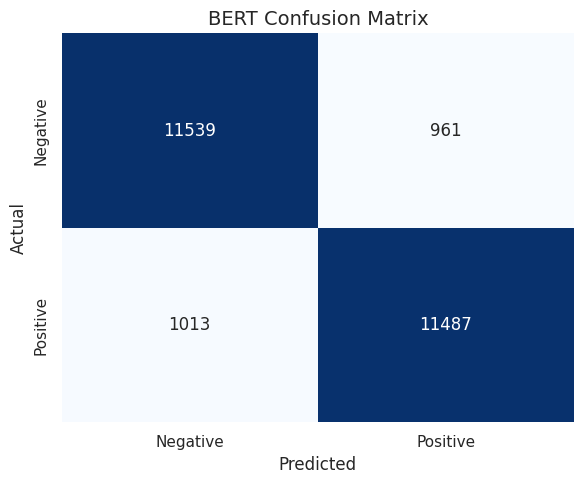

In [ ]:
print("Evaluating BERT...")

bert_predictions = bert_trainer.predict(tokenized_dataset["test"])
bert_logits = bert_predictions.predictions
bert_preds = np.argmax(bert_logits, axis=-1)
bert_probs = np.exp(bert_logits) / np.exp(bert_logits).sum(axis=-1, keepdims=True)
test_labels = tokenized_dataset["test"]["labels"]

bert_metrics = {
    "Model": "BERT",
    "Accuracy": accuracy_score(test_labels, bert_preds),
    "Precision": precision_score(test_labels, bert_preds, zero_division=0),
    "Recall": recall_score(test_labels, bert_preds, zero_division=0),
    "F1-score": f1_score(test_labels, bert_preds, zero_division=0),
}

print("\nBERT Metrics:")
for k, v in bert_metrics.items():
    if k != "Model":
        print(f"{k}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(test_labels, bert_preds, target_names=["Negative", "Positive"]))

bert_cm = confusion_matrix(test_labels, bert_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(bert_cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.title("BERT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("bert_confusion_matrix.png", dpi=300)
plt.show()

In [ ]:
# ============================================================
# BERT COMPLETE EXPORT PIPELINE
# ============================================================

import os
import json
import shutil
import numpy as np
import pandas as pd

SAVE_DIR = "bert_results"

os.makedirs(SAVE_DIR, exist_ok=True)

print("=" * 60)
print("SAVING MODEL + TOKENIZER")
print("=" * 60)

bert_model.save_pretrained(SAVE_DIR)
bert_tokenizer.save_pretrained(SAVE_DIR)

print("PASS: MODEL + TOKENIZER SAVED")

# ============================================================
# SAVE TEST METRICS
# ============================================================

with open(f"{SAVE_DIR}/test_metrics.json", "w") as f:
    json.dump(bert_metrics, f, indent=4)

print("PASS: TEST METRICS SAVED")

# ============================================================
# SAVE TRAIN METRICS
# ============================================================

train_metrics = {
    "train_runtime_minutes": bert_train_time / 60,
    "epochs": training_args.num_train_epochs,
    "learning_rate": training_args.learning_rate,
    "train_batch_size": training_args.per_device_train_batch_size,
    "eval_batch_size": training_args.per_device_eval_batch_size,
    "weight_decay": training_args.weight_decay,
    "warmup_steps": training_args.warmup_steps
}

with open(f"{SAVE_DIR}/train_metrics.json", "w") as f:
    json.dump(train_metrics, f, indent=4)

print("PASS: TRAIN METRICS SAVED")

# ============================================================
# SAVE EXPERIMENT CONFIG
# ============================================================

experiment_config = {
    "model_name": BERT_MODEL,
    "max_length": 256,
    "epochs": training_args.num_train_epochs,
    "learning_rate": training_args.learning_rate,
    "train_batch_size": training_args.per_device_train_batch_size,
    "eval_batch_size": training_args.per_device_eval_batch_size,
    "weight_decay": training_args.weight_decay,
    "warmup_steps": training_args.warmup_steps,
    "fp16": training_args.fp16
}

with open(f"{SAVE_DIR}/experiment_config.json", "w") as f:
    json.dump(experiment_config, f, indent=4)

print("PASS: EXPERIMENT CONFIG SAVED")

# ============================================================
# SAVE TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(
    bert_trainer.state.log_history
)

history_df.to_csv(
    f"{SAVE_DIR}/training_history.csv",
    index=False
)

print("PASS: TRAINING HISTORY SAVED")

# ============================================================
# SAVE NUMPY ARTIFACTS
# ============================================================

np.save(f"{SAVE_DIR}/labels.npy", np.array(test_labels))
np.save(f"{SAVE_DIR}/predictions.npy", np.array(bert_preds))
np.save(f"{SAVE_DIR}/logits.npy", np.array(bert_logits))
np.save(f"{SAVE_DIR}/probabilities.npy", np.array(bert_probs))

print("PASS: NUMPY ARTIFACTS SAVED")

# ============================================================
# SAVE CLASSIFICATION REPORT
# ============================================================

report_dict = classification_report(
    test_labels,
    bert_preds,
    target_names=["Negative", "Positive"],
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

report_df.to_csv(
    f"{SAVE_DIR}/classification_report.csv"
)

print("PASS: CLASSIFICATION REPORT SAVED")

# ============================================================
# SAVE PREDICTION ANALYSIS
# ============================================================

confidence_scores = bert_probs.max(axis=1)

analysis_df = pd.DataFrame({
    "text": test_data["text"],
    "true_label": test_labels,
    "predicted_label": bert_preds,
    "confidence": confidence_scores
})

analysis_df.to_csv(
    f"{SAVE_DIR}/prediction_analysis.csv",
    index=False
)

print("PASS: PREDICTION ANALYSIS SAVED")

# ============================================================
# SAVE CONFUSION MATRIX
# ============================================================

pd.DataFrame(bert_cm).to_csv(
    f"{SAVE_DIR}/confusion_matrix.csv",
    index=False
)

print("PASS: CONFUSION MATRIX SAVED")

# ============================================================
# ZIP EVERYTHING
# ============================================================

shutil.make_archive(
    SAVE_DIR,
    "zip",
    SAVE_DIR
)

print("=" * 60)
print("BERT EXPORT COMPLETE")
print("=" * 60)

print(f"ZIP READY: {SAVE_DIR}.zip")

SAVING MODEL + TOKENIZER


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

PASS: MODEL + TOKENIZER SAVED
PASS: TEST METRICS SAVED
PASS: TRAIN METRICS SAVED
PASS: EXPERIMENT CONFIG SAVED
PASS: TRAINING HISTORY SAVED
PASS: NUMPY ARTIFACTS SAVED
PASS: CLASSIFICATION REPORT SAVED
PASS: PREDICTION ANALYSIS SAVED
PASS: CONFUSION MATRIX SAVED
BERT EXPORT COMPLETE
ZIP READY: bert_results.zip


In [ ]:
# ============================================================
# GENERATE MISSING BERT ARTIFACTS
# ============================================================

import os
import json
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
from safetensors.torch import save_file
import torch

BERT_RESULTS_DIR = "transformer_results/bert_results"

os.makedirs(BERT_RESULTS_DIR, exist_ok=True)

print("=" * 60)
print("GENERATING MISSING BERT FILES")
print("=" * 60)

# ============================================================
# CONFUSION MATRIX CSV
# ============================================================

cm = confusion_matrix(test_labels, bert_preds)

cm_df = pd.DataFrame(
    cm,
    index=["Actual_Negative", "Actual_Positive"],
    columns=["Predicted_Negative", "Predicted_Positive"]
)

cm_path = os.path.join(BERT_RESULTS_DIR, "confusion_matrix.csv")
cm_df.to_csv(cm_path)

print("PASS: confusion_matrix.csv saved")

# ============================================================
# PREDICTION ANALYSIS CSV
# ============================================================

confidence_scores = np.max(bert_probs, axis=1)

prediction_analysis_df = pd.DataFrame({
    "text": dataset["test"]["text"],
    "true_label": test_labels,
    "predicted_label": bert_preds,
    "confidence": confidence_scores
})

analysis_path = os.path.join(BERT_RESULTS_DIR, "prediction_analysis.csv")
prediction_analysis_df.to_csv(analysis_path, index=False)

print("PASS: prediction_analysis.csv saved")

# ============================================================
# MODEL.SAFETENSORS
# ============================================================

model_state_dict = bert_model.state_dict()

safe_model_path = os.path.join(BERT_RESULTS_DIR, "model.safetensors")
save_file(model_state_dict, safe_model_path)

print("PASS: model.safetensors saved")

# ============================================================
# TOKENIZER.JSON
# ============================================================

tokenizer_json_path = os.path.join(BERT_RESULTS_DIR, "tokenizer.json")

if os.path.exists("bert_finetuned/tokenizer.json"):
    import shutil
    shutil.copy(
        "bert_finetuned/tokenizer.json",
        tokenizer_json_path
    )
    print("PASS: tokenizer.json copied")
else:
    bert_tokenizer.save_pretrained(BERT_RESULTS_DIR)
    print("PASS: tokenizer.json regenerated")

print("=" * 60)
print("ALL MISSING BERT FILES GENERATED")
print("=" * 60)

GENERATING MISSING BERT FILES


NameError: name 'test_labels' is not defined